In [48]:
import pandas as pd  
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [49]:
df = pd.read_csv('/Users/manish/Developer/ML_Project/job_salary_prediction_dataset.csv')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [51]:
df.shape

(250000, 10)

In [52]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [53]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


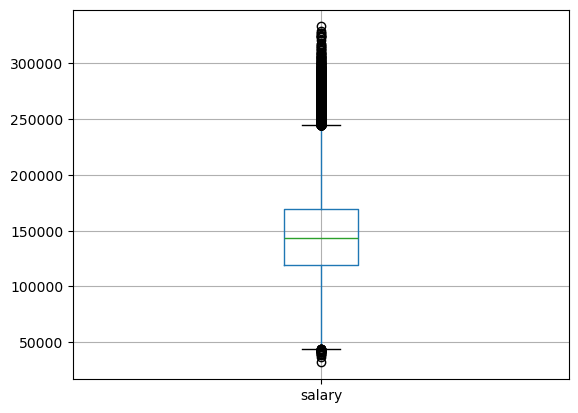

In [54]:
df.boxplot(column='salary')
plt.show()

In [55]:
from scipy.stats.mstats import winsorize
df['salary'] = winsorize(df['salary'], limits=[0.01, 0.05])

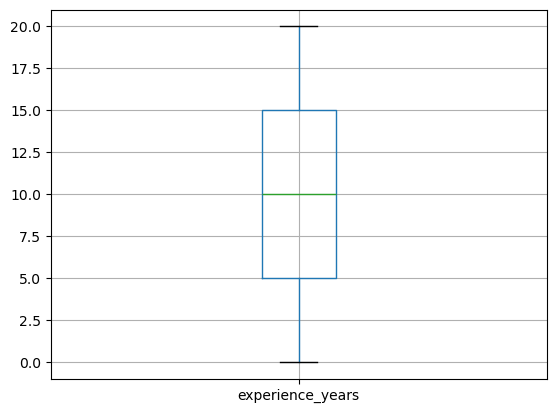

In [56]:
df.boxplot(column='experience_years')
plt.show()

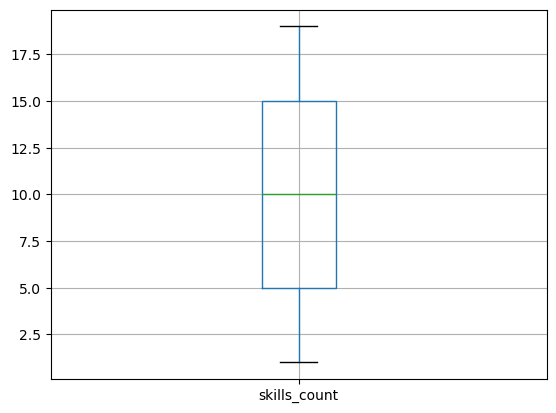

In [57]:
df.boxplot(column='skills_count')
plt.show()

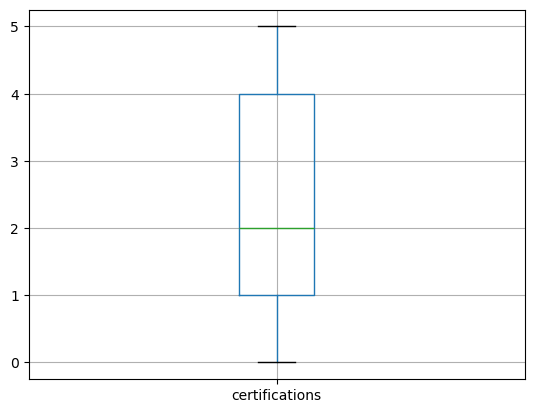

In [58]:
df.boxplot(column='certifications')
plt.show()

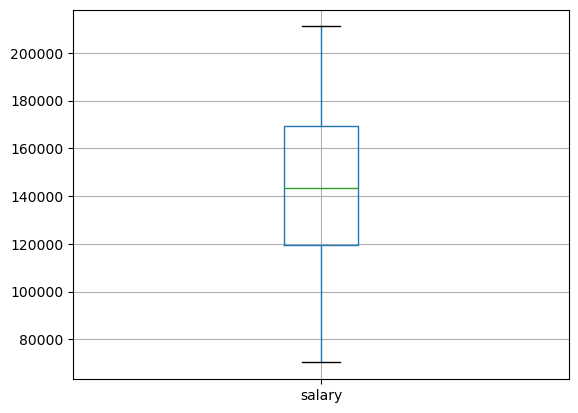

In [59]:
df.boxplot(column='salary')
plt.show()

In [60]:
df['salary'] = np.log1p(df['salary'])

In [61]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(12)

In [63]:
from sklearn.model_selection import train_test_split
X = df.drop('salary', axis=1)
y = df['salary']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [65]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [66]:
# List all columns you put in your ColumnTransformer
expected_cols = [
    'job_title', 'company_size', 'location', 
    'education_level', 'remote_work', 
    'experience_years', 'skills_count'
]

# Find which ones are NOT in your training data
missing = [col for col in expected_cols if col not in X_train.columns]

if missing:
    print(f"❌ Missing columns found: {missing}")
else:
    print("✅ All columns match perfectly. If it still fails, check for 'industry' or others in 'remainder'.")

✅ All columns match perfectly. If it still fails, check for 'industry' or others in 'remainder'.


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder , OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('Ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),
         ['job_title', 'company_size', 'location', 'industry']),
        ('Ordinal', OrdinalEncoder(), ['education_level', 'remote_work']),
        ('scalar', StandardScaler(), ['experience_years', 'skills_count', 'certifications'])
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 0.005520659277376339
R^2 Score: 0.9141845595325341


In [68]:
from sklearn.tree import DecisionTreeRegressor
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
]) 
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f'Decision Tree - Mean Squared Error: {mse_dt}')
print(f'Decision Tree - R^2 Score: {r2_dt}')

Decision Tree - Mean Squared Error: 0.00502029784822317
Decision Tree - R^2 Score: 0.9219623871937471


In [69]:
from sklearn.ensemble import RandomForestRegressor
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest - Mean Squared Error: {mse_rf}')
print(f'Random Forest - R^2 Score: {r2_rf}')

Random Forest - Mean Squared Error: 0.0024618116046382626
Random Forest - R^2 Score: 0.9617325691397581


In [70]:
import joblib

# Save all trained models/pipelines as .pkl files
joblib.dump(pipeline, "linear_regression_pipeline.pkl")
joblib.dump(pipeline_dt, "decision_tree_pipeline.pkl")
joblib.dump(pipeline_rf, "random_forest_pipeline.pkl")

print("Saved:")
print("- linear_regression_pipeline.pkl")
print("- decision_tree_pipeline.pkl")
print("- random_forest_pipeline.pkl")

Saved:
- linear_regression_pipeline.pkl
- decision_tree_pipeline.pkl
- random_forest_pipeline.pkl
